<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/week5_day4_dalychallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install gensim spacy torch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 2. Load and Preprocess the Dataset

# Create a dummy stock market dataset for demonstration
dates = pd.to_datetime(pd.date_range(start='2020-01-01', periods=100, freq='D'))
close_prices = np.random.rand(100) * 100 + 50 # Random prices between 50 and 150
open_prices = close_prices * (1 + (np.random.rand(100) - 0.5) * 0.1)
high_prices = np.maximum(open_prices, close_prices) * (1 + np.random.rand(100) * 0.05)
low_prices = np.minimum(open_prices, close_prices) * (1 - np.random.rand(100) * 0.05)
volume = np.random.randint(1000000, 5000000, 100)

df = pd.DataFrame({
    'Date': dates,
    'Open': open_prices,
    'High': high_prices,
    'Low': low_prices,
    'Close': close_prices,
    'Volume': volume
})

# Set Date as index
df.set_index('Date', inplace=True)

print("Original DataFrame head:")
print(df.head())

# Drop unnecessary columns (for this example, we'll keep all for now and select features later)
# If there were clearly irrelevant columns, they would be dropped here.

# Create a target column for the next day’s closing price
df['Target'] = df['Close'].shift(-1)

# Drop the last row as it will have NaN for the 'Target'
df.dropna(inplace=True)

print("\nDataFrame with Target column and NaN dropped:")
print(df.head())
print(f"DataFrame shape after adding target and dropping NaNs: {df.shape}")

# Normalize the dataset using MinMaxScaler
# We will normalize all numerical features including 'Close' and 'Target'

# Separate features and target for scaling
features = ['Open', 'High', 'Low', 'Close', 'Volume']

# Initialize MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit and transform the features
df_scaled = pd.DataFrame(scaler.fit_transform(df[features]), columns=features, index=df.index)

# Scale the target separately to ensure proper inverse transformation later
scaler_target = MinMaxScaler(feature_range=(-1, 1))
df_scaled['Target'] = scaler_target.fit_transform(df[['Target']])

print("\nScaled DataFrame head:")
print(df_scaled.head())
print(f"Scaled DataFrame shape: {df_scaled.shape}")

Original DataFrame head:
                  Open        High         Low       Close   Volume
Date                                                               
2020-01-01  100.652676  104.573919   97.853753   98.680665  1793681
2020-01-02   72.182273   75.668291   67.601690   71.084454  3059600
2020-01-03   58.495513   62.892026   55.714547   60.152364  4436544
2020-01-04  110.069228  114.112696  103.567983  106.496181  3229772
2020-01-05  110.711676  115.173697  107.580093  110.454598  1302064

DataFrame with Target column and NaN dropped:
                  Open        High         Low       Close   Volume  \
Date                                                                  
2020-01-01  100.652676  104.573919   97.853753   98.680665  1793681   
2020-01-02   72.182273   75.668291   67.601690   71.084454  3059600   
2020-01-03   58.495513   62.892026   55.714547   60.152364  4436544   
2020-01-04  110.069228  114.112696  103.567983  106.496181  3229772   
2020-01-05  110.711676  11

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

# 3. Prepare the Dataset for Training

# Define sequence length
sequence_length = 10

# Create sequences for LSTM
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length, -1]  # Target is the last column of the next step
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Convert scaled DataFrame to numpy array
data_np = df_scaled.values

X, y = create_sequences(data_np, sequence_length)

print(f"Shape of X (sequences): {X.shape}")
print(f"Shape of y (targets): {y.shape}")

# Split the dataset into training, validation, and testing sets
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

print(f"\nTrain set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

# Create a custom PyTorch Dataset class
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create Dataset instances
train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)
test_dataset = StockDataset(X_test, y_test)

# Use DataLoader to create iterable datasets for training and evaluation
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("\nDataLoaders created successfully.")
for xb, yb in train_loader:
    print(f"Batch X shape: {xb.shape}, Batch y shape: {yb.shape}")
    break

Shape of X (sequences): (89, 10, 6)
Shape of y (targets): (89,)

Train set size: 62
Validation set size: 13
Test set size: 14

DataLoaders created successfully.
Batch X shape: torch.Size([32, 10, 6]), Batch y shape: torch.Size([32])


In [4]:
import torch.nn as nn

# 4. Define the LSTM Model

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_layer_size, num_layers, output_size, dropout_rate=0.5):
        super(LSTMModel, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers

        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True, dropout=dropout_rate)

        # Dropout layer (if dropout_rate > 0)
        self.dropout = nn.Dropout(dropout_rate)

        # Linear layer for output
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, input_seq.size(0), self.hidden_layer_size).to(input_seq.device)
        c0 = torch.zeros(self.num_layers, input_seq.size(0), self.hidden_layer_size).to(input_seq.device)

        # Pass through LSTM layer
        lstm_out, _ = self.lstm(input_seq, (h0, c0))

        # Get the output of the last time step
        # Apply dropout to the output of the LSTM layer
        dropout_out = self.dropout(lstm_out[:, -1, :])

        # Pass through the linear layer
        predictions = self.linear(dropout_out)
        return predictions

# Model parameters
input_size = X_train.shape[2]  # Number of features (e.g., Open, High, Low, Close, Volume, Target)
hidden_layer_size = 64
num_layers = 2
output_size = 1 # Predicting next day's 'Target' (Close price)
dropout_rate = 0.2

# Instantiate the model
model = LSTMModel(input_size, hidden_layer_size, num_layers, output_size, dropout_rate)

print("LSTM Model Architecture:")
print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

LSTM Model Architecture:
LSTMModel(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)
Number of parameters: 51777


Training model on cpu...
Epoch [1/50], Train Loss: 0.4048, Val Loss: 0.3686
Epoch [2/50], Train Loss: 0.3978, Val Loss: 0.3540
Epoch [3/50], Train Loss: 0.3947, Val Loss: 0.3436
Epoch [4/50], Train Loss: 0.3841, Val Loss: 0.3360
Epoch [5/50], Train Loss: 0.3901, Val Loss: 0.3312
Epoch [6/50], Train Loss: 0.3821, Val Loss: 0.3288
Epoch [7/50], Train Loss: 0.3766, Val Loss: 0.3276
Epoch [8/50], Train Loss: 0.3820, Val Loss: 0.3275
Epoch [9/50], Train Loss: 0.3823, Val Loss: 0.3281
Epoch [10/50], Train Loss: 0.3842, Val Loss: 0.3292
Epoch [11/50], Train Loss: 0.3748, Val Loss: 0.3301
Epoch [12/50], Train Loss: 0.3739, Val Loss: 0.3314
Epoch [13/50], Train Loss: 0.3737, Val Loss: 0.3323
Epoch [14/50], Train Loss: 0.3716, Val Loss: 0.3342
Epoch [15/50], Train Loss: 0.3619, Val Loss: 0.3349
Epoch [16/50], Train Loss: 0.3701, Val Loss: 0.3351
Epoch [17/50], Train Loss: 0.3694, Val Loss: 0.3358
Epoch [18/50], Train Loss: 0.3677, Val Loss: 0.3361
Epoch [19/50], Train Loss: 0.3574, Val Loss: 0.3

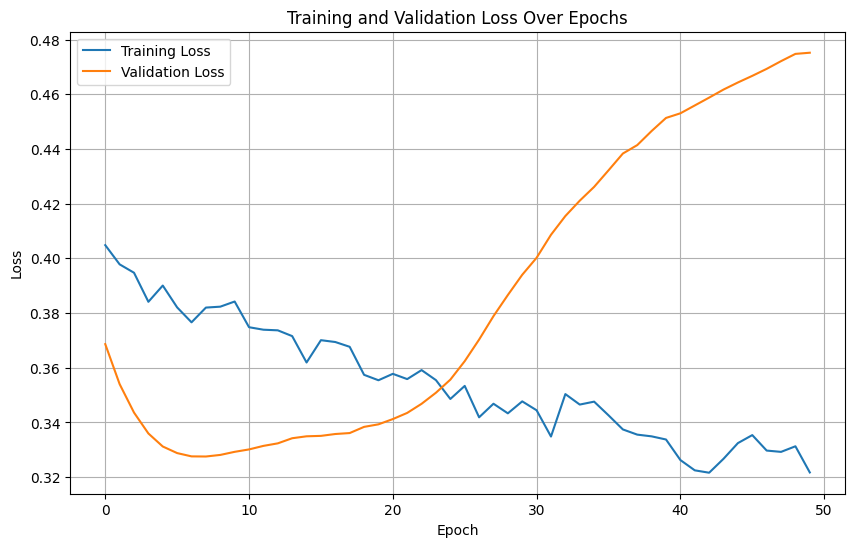

In [5]:
import torch.optim as optim
import matplotlib.pyplot as plt

# 5. Train the Model

# Set device for training (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Set up the optimizer and loss function
learning_rate = 0.001
epochs = 50

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss() # Mean Squared Error for regression

# Training and Validation Loops
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    train_losses = []
    val_losses = []

    print(f"Training model on {device}...")

    for epoch in range(epochs):
        model.train() # Set model to training mode
        running_train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.unsqueeze(1) # Ensure target shape matches model output

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval() # Set model to evaluation mode
        running_val_loss = 0.0
        with torch.no_grad(): # Disable gradient calculations during validation
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                targets = targets.unsqueeze(1)

                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * inputs.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}')

    print("Training complete!")
    return train_losses, val_losses

train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device)

# Plotting training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


R² Score on Test Set: 0.0974


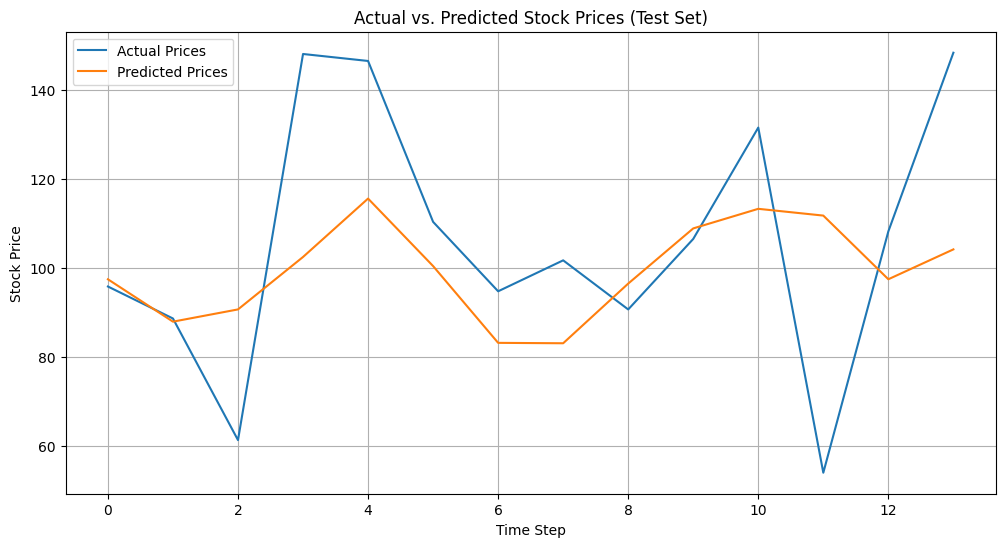


Model and Scalers saved successfully.


In [6]:
from sklearn.metrics import r2_score
import joblib # For saving/loading scaler objects

# 6. Evaluate the Model

model.eval() # Set model to evaluation mode

predictions = []
actuals = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predictions.extend(outputs.squeeze().cpu().numpy())
        actuals.extend(targets.squeeze().cpu().numpy())

# Convert to numpy arrays
predictions = np.array(predictions)
actuals = np.array(actuals)

# Inverse transform the predictions and actuals to original scale
# We need to reshape for inverse_transform, as scaler expects 2D array
predictions_original_scale = scaler_target.inverse_transform(predictions.reshape(-1, 1))
actuals_original_scale = scaler_target.inverse_transform(actuals.reshape(-1, 1))

# Calculate R² score
r2 = r2_score(actuals_original_scale, predictions_original_scale)

print(f"\nR² Score on Test Set: {r2:.4f}")

# Plotting actual vs. predicted values (on original scale)
plt.figure(figsize=(12, 6))
plt.plot(actuals_original_scale, label='Actual Prices')
plt.plot(predictions_original_scale, label='Predicted Prices')
plt.title('Actual vs. Predicted Stock Prices (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

# Save the scaler object for future predictions
# It's good practice to save the model and scaler used for preprocessing
joblib.dump(scaler, 'min_max_scaler_features.pkl')
joblib.dump(scaler_target, 'min_max_scaler_target.pkl')
torch.save(model.state_dict(), 'lstm_model.pth')

print("\nModel and Scalers saved successfully.")